# 5EL272 Systems and algorithms for Autonomous Vehicles
## Exercise 4: Reinforcement Learning
Created byTomas Nordström, Umeå University

The basic concept for this lab comes from previous years in this course (then as Lab3). But due to the use of obsolete python packages, the lab has been reconstructed and is now based on stable_baselines3 together with the highway environment and the gymnasium gym environment. Especially  https://highway-env.farama.org/quickstart/ together with code-fixes and a colab link according to: https://github.com/Farama-Foundation/HighwayEnv/issues/631

Revisions:
* 2025-01-05 First version /Tomas
* 2025-01-07 Merge of different versions, general editing /Godwin
* 2025-01-08 Cleanup before release /Tomas

This Exercise is based on highway-env https://github.com/eleurent/highway-env. Here the ego-vehicle is rewarded for reaching a high speed and avoiding collisions during highway driving (highway-env). Your task is run a car for a long time and as good speed as possible without colliding with any other car.

You can modify both the reward functions as well as the DQN model in order to achieve as good system as possible. The hyper parameters for the environment (scenario and rewards) are defined in env_config, while the DQN model parameters are defined when DQN is instantiated `model = DQN(..)`.

You may use either Google CoLab or your local machine. Even if you use a local machine your submission should be a Colab link to your notebook, thus you need to upload the notebook before submission. Please include the recorded videos during the testing in the submitted IPython Notebook. It is not realistic for us to retrain all the models, so please provide screenshots and descriptions in the report for your observations of each config, esp. "the two configs that differ only in the lane_change_reward, one with no or rare collisions, one with frequent collisions".

Note: More complex environments demand more training time (more num_episodes), so do not make your environment more complex than necessary. You may try increasing the  vehicles_density and reward_speed_range to increase the chances of collision. You may also find "[Keep Google Colab from disconnecting](https://gist.github.com/pouyaardehkhani/29a59270801a209d4960e2aefe648bbc)" to be helpful (I think this comes from "[Script to Stop Google Colab From Disconnecting](https://www.rockyourcode.com/script-to-stop-google-colab-from-disconnecting/)").




##Summary of Exercise Goals


* Understand autonomous driving environment

    Explore the Highway environment for autonomous driving, where you will create, visualize, and configure the environment to include various variations.
*   Experiment with Rewards

    Explore how various rewards will influence the behaviour of the vehicle.

*   Experiment with Deep Q-Learning

    Explore how to apply deep Q-learning to optimize the speed of the ego vehicle while safely avoiding collisions with other vehicles. You will design and fine-tune various hyperparameters and interpret key performance metrics to enhance your understanding and results.




# Set up the python environment

In [81]:
#### Set up tests to know if we are running Colab or Kaggle
import sys, os

### Is this notebook running on Colab?
IS_COLAB = "google.colab" in sys.modules

### Is this notebook running on Kaggle?
# Fool Kaggle into making kaggle_secrets avaiable
try:
    import kaggle_secrets
except ImportError as e:
    pass
# Now we can test for Kaggle
IS_KAGGLE = "kaggle_secrets" in sys.modules

In [82]:
# We are not using Keras or TF in this code, but we still set it up.
os.environ["KERAS_BACKEND"] = "tensorflow" # Also tensorflow, jax,pytorch for Keras 3.0

# Import Keras/TF libraries

import keras
print('Keras version:', keras.__version__)

import tensorflow as tf
print('TensorFlow version:', tf.__version__)

Keras version: 3.13.0
TensorFlow version: 2.19.1


In [83]:
# Helper libraries
import os
import numpy as np
from numpy import argmax
import time

# Matlab plotting
import matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt
# To plot pretty figures
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
%matplotlib inline

import pprint

In [84]:
!pip install git+https://github.com/eleurent/highway-env.git
!pip install git+https://github.com/eleurent/highway-env.git

!pip install tensorboardx pyvirtualdisplay #gym
!apt-get install -y xvfb ffmpeg


  Cloning https://github.com/eleurent/highway-env.git to /private/var/folders/fd/bywvldn11db7qy_6g7qh55f80000gn/T/pip-req-build-yu0ctnlj
  Running command git clone --filter=blob:none --quiet https://github.com/eleurent/highway-env.git /private/var/folders/fd/bywvldn11db7qy_6g7qh55f80000gn/T/pip-req-build-yu0ctnlj
  Resolved https://github.com/eleurent/highway-env.git to commit b9180dfaef13c3c87eeb43f56f37b0e42d9d0476
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/eleurent/highway-env.git to /private/var/folders/fd/bywvldn11db7qy_6g7qh55f80000gn/T/pip-req-build-2539uz6z
  Running command git clone --filter=blob:none --quiet https://github.com/eleurent/highway-env.git /private/var/folders/fd/bywvldn11db7qy_6g7qh55f80000gn/T/pip-req-build-2539uz6z
  Resolved https://github.com/eleurent/highway-env.git to commit b9180dfaef13c3c87eeb43f56f37b0e42d9d0476
  Installing build de

In [ ]:
# Install environment and agent
# We use the bleeding edge version because the current stable version does not support everything ww want
if (IS_COLAB or IS_KAGGLE):
    !pip install -q git+https://github.com/eleurent/highway-env
    !pip install -q git+https://github.com/DLR-RM/stable-baselines3
    # !pip install -q git+https://github.com/araffin/sbx

# Environment https://github.com/Farama-Foundation/Gymnasium and https://github.com/eleurent/highway-env
import gymnasium as gym
import highway_env

gym.register_envs(highway_env)

# Agent
from stable_baselines3 import DQN, PPO
# from sbx import DQN  # (if we want to try using jax)

# Visualization utils
%load_ext tensorboard
import sys
from tqdm.notebook import trange

if (IS_COLAB or IS_KAGGLE):
    !pip install -q tensorboardx pyvirtualdisplay #gym
    !apt-get install -y xvfb ffmpeg
    !git clone https://github.com/Farama-Foundation/HighwayEnv.git 2> /dev/null
    sys.path.insert(0, '/content/HighwayEnv/scripts/')
else:
    sys.path.insert(0, '/HighwayEnv/scripts') # Update path to where your local HighwayEnv is installed!


#from utils import record_videos, show_videos
from utils_local import record_videos, show_videos


The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


# Set up simulation environment

Here we use the [Highway environment](https://highway-env.farama.org/environments/highway/) by farama, that is integrated with the gymnasium framework. We also use stable-baselines3 for the RL-agents. For this lab we will use a 3-lane (straight) highway senario.

* **Observations**: The sensing the Ego vehicle will do is an *Occupancy grid*
* **Actions**: The action space for the Ego vehicle, is "DiscreteMetaAction", that is: {'LANE_LEFT', 'IDLE', 'LANE_RIGHT', 'FASTER', 'SLOWER'}
* **Rewards**: The vehicle will be rewarded for progressing quickly on the road;and avoiding collisions. In addition we have rewards like: 'lane_change_reward' and 'right_lane_reward'.




## Occupancy grid observations

The OccupancyGridObservation is a $W \times H \times F$ array, that represents a grid of shape $W \times H $ discretising the space $(X,Y)$ around the ego-vehicle in uniform rectangle cells. Each cell is described by $F$ features, listed in the "features" configuration field. The grid size and resolution is defined by the grid_size and grid_steps configuration fields.

The number $V$ of vehicles is constant and configured by the vehicles_count field, so that the observation has a fixed size. If fewer vehicles than vehicles_count are observed, the last rows are placeholders filled with zeros. The presence feature can be used to detect such cases, since it is set to 1 for any observed vehicle and 0 for placeholders.

| Feature    | Description     |
| ------------- | ------------- |
| presence | The presence of a vehicle is indicated with 1 |
| x  | World offset of ego vehicle or offset to ego vehicle on the x axis.|
| y  | World offset of ego vehicle or offset to ego vehicle on the y axis. |
| vx  | Velocity on the x axis of vehicle. |
| vy  | Velocity on the y axis of vehicle. |
| $cos_h$  | Trigonometric heading of vehicle. |
| $sin_h$   | Trigonometric heading of vehicle. |


## Actions
The Highway sim have a number of [actions](https://highway-env.farama.org/actions/index.html), and we will in this lab use the "DiscreteMetaAction".

"The DiscreteMetaAction type adds a layer of speed and steering controllers on top of the continuous low-level control, so that the ego-vehicle can automatically follow the road at a desired velocity. Then, the available meta-actions consist in changing the target lane and speed that are used as setpoints for the low-level controllers."

The full corresponding action space is defined in ACTIONS_ALL
```
ACTIONS_ALL = {
        0: 'LANE_LEFT',
        1: 'IDLE',
        2: 'LANE_RIGHT',
        3: 'FASTER',
        4: 'SLOWER'
    }
```
Some of these actions might not be always available (lane changes at the edges of the roads, or accelerating/decelrating beyond the maximum/minimum velocity), and the list of available actions can be accessed with get_available_actions() method. Taking an unavailable action is equivalent to taking the IDLE action.

## Do the configuration of the whole environment

In [ ]:
# https://highway-env.farama.org/observations/
# https://lavinama.github.io/highway-env/observations/index.html

env_config={
        'lanes_count': 3,
        'vehicles_count': 20,
        'initial_lane_id': 0,
        "observation": {
            "type": "OccupancyGrid",
            "vehicles_count": 15,
            "features": ["presence", "x", "y", "vx", "vy", "cos_h", "sin_h"],
            "features_range": {
                "x": [-100, 100],
                "y": [-100, 100],
                "vx": [-20, 20],
                "vy": [-20, 20]
            },
            "grid_size": [[-27.5, 27.5], [-27.5, 27.5]],
            "grid_step": [5, 5],
            "absolute": False
        },
        'lane_change_reward': -0.1,
        'right_lane_reward': 0.1,
        'high_speed_reward': 0.4,
        'collision_reward': -1,
}

def env_create(seed=42):
    env = gym.make('highway-fast-v0', config=env_config, render_mode='rgb_array')
    # pprint.pprint(env.unwrapped.config)
    env.reset(seed=seed)
    return env

{'action': {'type': 'DiscreteMetaAction'},
 'centering_position': [0.3, 0.5],
 'collision_reward': -1,
 'controlled_vehicles': 1,
 'duration': 30,
 'ego_spacing': 1.5,
 'high_speed_reward': 0.4,
 'initial_lane_id': 0,
 'lane_change_reward': -0.1,
 'lanes_count': 3,
 'manual_control': False,
 'normalize_reward': True,
 'observation': {'absolute': False,
                 'features': ['presence',
                              'x',
                              'y',
                              'vx',
                              'vy',
                              'cos_h',
                              'sin_h'],
                 'features_range': {'vx': [-20, 20],
                                    'vy': [-20, 20],
                                    'x': [-100, 100],
                                    'y': [-100, 100]},
                 'grid_size': [[-27.5, 27.5], [-27.5, 27.5]],
                 'grid_step': [5, 5],
                 'type': 'OccupancyGrid',
                 'vehicle

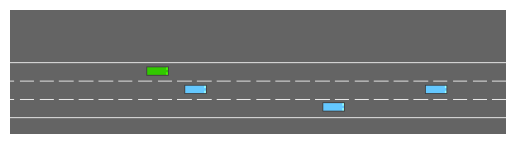

In [113]:
env = env_create()
pprint.pprint(env.unwrapped.config) # Print all the env parameters

for _ in range(3):
    action = env.unwrapped.action_type.actions_indexes["IDLE"]
    obs, reward, done, truncated, info = env.step(action)
    env.render()

plt.imshow(env.render()) # draw the current scenario
plt.axis('off')
plt.show()

## Explore the observations the model will use as input

In [88]:
# Get on (random) starting observation
obs, info = env.reset()
print(obs.shape)

(7, 11, 11)


STUDENT Question:
* Explain each of the output dimensions (shape) of the observation, what do each of them 


YOUR Answer: *Your answer here!*

The shape (7,11,11) of the obervation 

In [89]:
# Find all grid points with an vehicle present
for i in range(obs.shape[1]):  # Iterate over the Occupancy grid
    for j in range(obs.shape[2]):
        if obs[0, i, j] > 0:   # Check if 'presence' feature is non-zero
            print(f"Grid point ({i}, {j}): {obs[:, i, j]}") # Print the feature vector at this grid point

Grid point (5, 5): [1. 0. 0. 0. 0. 1. 0.]
Grid point (9, 7): [ 1.          0.21116701  0.08       -0.16490908  0.          1.
  0.        ]


STUDENT Question:
* Describe each of these detected vehicles (what do the feature vectors tell us?)

YOUR Answer: *Your answer here!*

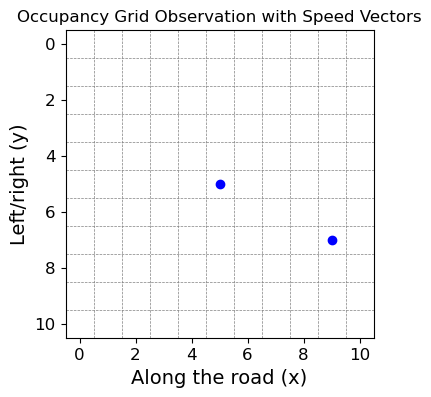

In [90]:
# Plot the Occupancy grid, from the obs state

# Extract grid dimensions and features
grid_height, grid_width = obs.shape[1], obs.shape[2]

# Create a figure for plotting
plt.figure(figsize=(4, 4))
plt.title("Occupancy Grid Observation with Speed Vectors")
plt.xlabel("Along the road (x)")
plt.ylabel("Left/right (y)")

# Draw the grid outline
for x in range(grid_height + 1):  # Vertical lines (rotated grid height)
    plt.axvline(x - 0.5, color='gray', linestyle='--', linewidth=0.5)
for y in range(grid_width + 1):  # Horizontal lines (rotated grid width)
    plt.axhline(y - 0.5, color='gray', linestyle='--', linewidth=0.5)

# Loop through each grid point (rotate coordinates)
for i in range(grid_height):  # Iterate over rows
    for j in range(grid_width):  # Iterate over columns
        # Check if 'presence' feature is non-zero
        if obs[0, i, j] > 0:  # Assuming 'presence' is the first feature
            # Extract the velocity components (vx, vy)
            vx, vy = obs[3, i, j], obs[4, i, j]

            # Plot the grid point as a marker
            plt.plot(i, j, 'bo')  # Plot a blue dot at the rotated position

            # Add a quiver to represent the velocity vector (rotated)
            plt.quiver(i, j, vy, -vx, angles='xy', scale_units='xy', scale=1, color='red')

# Set axis limits and aspect ratio
plt.xlim(-0.5, grid_height - 0.5)
plt.ylim(-0.5, grid_width - 0.5)
plt.gca().invert_yaxis()  # Invert Y-axis for correct orientation
plt.gca().set_aspect('equal', adjustable='box')

# Show the plot
plt.show()

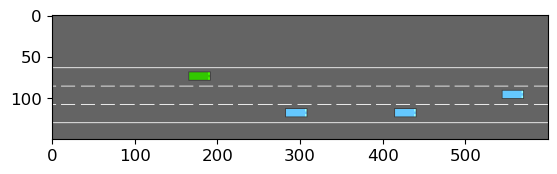

In [91]:
plt.imshow(env.render())

STUDENT Question:
* Why are there more vehicles when we do env.render than we find in our observations?

YOUR Answer: *Your answer here!*

# Training

In [92]:
# Track training using tensorboard to visualize training.
# https://datascience.stackexchange.com/questions/115243/understanding-the-tensorboard-plots-on-a-stable-baseline3s-ppo

#%tensorboard --logdir "highway_dqn"

Set up a [DQN model](https://stable-baselines3.readthedocs.io/en/master/modules/dqn.html) using stable-baselines3 ([src](https://github.com/DLR-RM/stable-baselines3/blob/master/stable_baselines3/dqn/dqn.py)). It has a large number of [parameters](https://stable-baselines3.readthedocs.io/en/master/modules/dqn.html#parameters), and we set some on them below.


In [93]:
model = DQN('MlpPolicy', env,
                policy_kwargs=dict(net_arch=[256, 256]),
                learning_rate=5e-4,
                buffer_size=15000,
                learning_starts=200,
                batch_size=32,
                gamma=0.8,
                train_freq=1,
                gradient_steps=1,
                target_update_interval=50,
                exploration_fraction=0.7,
                verbose=1,
                tensorboard_log='highway_dqn/')

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


STUDENT Question:
* Here we use something called DQN, explain how it differs from Q-learning?
* Could we have used Q-learning for this scenario?

YOUR Answer: *Your answer here!*

In [94]:
# This takes approx 2 minutes with a RTX3090, with 5000 time steps
# One clearly get better results at 15000 steps,
# but we need to balance this exploration with how quickly colab will kick you out.
start = time.perf_counter()
model.learn(total_timesteps=5000)
end = time.perf_counter()

s2mps = lambda s: f"{s // 60:.0f} min {s % 60:.2f} s"
print(f"Time to run: {s2mps(end - start)}")

Logging to highway_dqn/DQN_4
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 5.75     |
|    ep_rew_mean      | 3.99     |
|    exploration_rate | 0.994    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 56       |
|    time_elapsed     | 0        |
|    total_timesteps  | 23       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 12.1     |
|    ep_rew_mean      | 8.88     |
|    exploration_rate | 0.974    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 59       |
|    time_elapsed     | 1        |
|    total_timesteps  | 97       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 11.1     |
|    ep_rew_mean      | 7.98     |
|    exploration_rate | 0.964    |
| time/               |   

STUDENT Question:
* What happens to the exploration_rate during training, why do we want such behaviour?
* With reference to Highway-v0, what will happen to the DQN if you set a large target update interval?
* What is the significance of buffer size? What will happen if it is set to zero?

YOUR Answer: *Your answer here!*

In [95]:
# If one wants to save and load a model
# model.save('dqn_highway_v4')
# model = DQN.load('dqn_highway_v4', env=env)

# Testing

There is no universal way of evaluating these kinds of RL models. Two natural methods are rewards-based and efficiency-based. With the rewards-based methods we can look at things like: (weighted) sum of rewards or average reward per step. While for efficiency-based rewards it will be application dependent, but for our highway scenario, we can define measures like: average time before collision, average distance traveled before collision (here we assume you will collide soon enough). But other measures like comfort should also be considered.

Here we will calculate Average time before collision, Average distance travelled, and Average cumulative reward, for $N=25$ test episodes.

In [96]:
# Here we look an N=25 episodes and calculate time to fail and distance traveled to fail
notests = 25  # Total number of episodes to evaluate the model

# Initialize lists to store results for each episode
tottimetofail = []  # Store the time to fail for each episode
totdistance = []    # Store the total distance traveled in each episode
totreward = []      # Store the cumulative reward for each episode

# Define the simulation frequency (steps per second), FIX: should be extracted from env_config
simulation_frequency = 15

for ix in range(notests):
    timetofail = 0  # Time steps until failure
    distance = 0    # Distance traveled
    sumreward = 0   # Cumulative reward
    done = truncated = False  # Flags to indicate episode termination

    obs, info = env.reset() # Reset the environment and get the initial observation

    # Run the episode until termination (either done or truncated)
    while not (done or truncated):
        # Use the trained model to predict the next action deterministically
        action, _states = model.predict(obs, deterministic=True)

        # Execute the action in the environment
        obs, reward, done, truncated, info = env.step(action)

        timetofail += 1  # Increment the time to fail by one time step
        sumreward += reward # Accumulate the reward received
        distance += info['speed'] / simulation_frequency # Update the total distance traveled

    # Append the results of this episode to the respective lists
    tottimetofail.append(timetofail)  # Add the time to fail
    totdistance.append(distance)     # Add the distance traveled
    totreward.append(sumreward)      # Add the cumulative reward

# Calculate and print the average results across all test episodes
print(f'Avg time to fail [s] = {np.sum(tottimetofail) / notests / simulation_frequency:.2f}')
print(f'Avg distance traveled [m]= {np.sum(totdistance) / notests:.2f}')
print(f'Avg reward = {np.sum(totreward) / notests:.2f}')

Avg time to fail [s] = 1.28
Avg distance traveled [m]= 34.67
Avg reward = 16.41


STUDENT Question:
* Which of these three measures do you consider is a good performance measure to be used in your continued experiments?
* If you repeat this particular experiment 3 times, how large variation in results do you get? How will this variation influence your hyperparameter search strategy, if at all?
* Tune the Reward functions and the DQN agent hyperparameters to achieve a maximum performance possible.
    * The minimum performance to get a pass is an average time before collision of 1.87 seconds, a minimum average distance of 40 meters, and an average cumulative reward of 19, without a significant increase in training time. Report the training time.
* Now analyse and summarize your experiment, what is your understanding of how the parameters you explored influence the vehicle behaviour?

YOUR Answer: *Your answer here!*

Visualize a few episodes

In [99]:
# Visualize a few episodes as mp4 movies and play them inline.
# NOTE: this code is currently "unstable", and can hang from time to time (at least with my local environment and ssh tunnels)
if True:
    env = env_create()  # Initialize the environment using a custom function `env_create`

    # Enable video recording for the environment
    env = record_videos(env)  # Wrap the environment to capture and save videos of the agent's behavior

    # Loop through a specified number of test episodes to evaluate the model
    for episode in trange(3, desc='Test episodes'):  # Use trange for progress tracking; run 3 test episodes
        (obs, info), done = env.reset(), False  # Reset the environment to start a new episode; initialize observation and done flag
        while not done:  # Continue until the episode ends
            # Use the trained model to predict the next action deterministically
            action, _ = model.predict(obs, deterministic=True)

            # Take the predicted action in the environment and observe the results
            obs, reward, done, truncated, info = env.step(int(action))
            # `obs`: next observation, `reward`: reward received, `done`: whether the episode has ended,
            # `truncated`: whether the episode was truncated, `info`: additional environment details

    # Close the environment after completing all test episodes
    env.close()

    # Display the recorded videos of the agent's performance
    show_videos()  # Custom function to render the recorded videos







Exception ignored in: <function tqdm.__del__ at 0x30f041940>
Traceback (most recent call last):
  File "/Users/rickard/.local/lib/python3.11/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/Users/rickard/.local/lib/python3.11/site-packages/tqdm/notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'
Exception ignored in: <function tqdm.__del__ at 0x30f041940>
Traceback (most recent call last):
  File "/Users/rickard/.local/lib/python3.11/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/Users/rickard/.local/lib/python3.11/site-packages/tqdm/notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'
Exception ignored in: <function tqdm.__del__ at 0x30f041940>
Traceback (most recent call last):
  File "/Users/rickard/.loca

Videos:
 - videos/rl-video-episode-0.mp4
 - videos/rl-video-episode-1.mp4
 - videos/rl-video-episode-2.mp4


# Bonus exercise

Implement PPO instead of DQN as a agent model. Explore and optimize the PPO parameters in order to achieve a good PPO performance, and report and analyze this parameter exploration.
Then compare these two methods (PPO and DQN) in aspects like performance, running time, ease of tuning etc.

In [98]:
from tqdm import trange


In [109]:
from IPython.display import Video, display
import glob

for video in sorted(glob.glob("videos/*.mp4")):
    print(video)
    display(Video(video, embed=True))


videos/rl-video-episode-0.mp4


videos/rl-video-episode-1.mp4


videos/rl-video-episode-2.mp4
